원본 이미지:
[[0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 9. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0.]]

필터 적용 결과 (엣지 강조):
[[-3. -5. -3.]
 [-5. 64. -5.]
 [-3. -5. -3.]]


C:\Users\kyb88\AppData\Local\Temp\ipykernel_16924\1631262994.py:37: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyb88\AppData\Local\Temp\ipykernel_16924\1631262994.py:37: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyb88\AppData\Local\Temp\ipykernel_16924\1631262994.py:37: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyb88\AppData\Local\Temp\ipykernel_16924\1631262994.py:37: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyb88\AppData\Local\Temp\ipykernel_16924\1631262994.py:37: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kyb88\AppData\Local\Temp\ipykernel_16924\1631262994.py:37: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from f

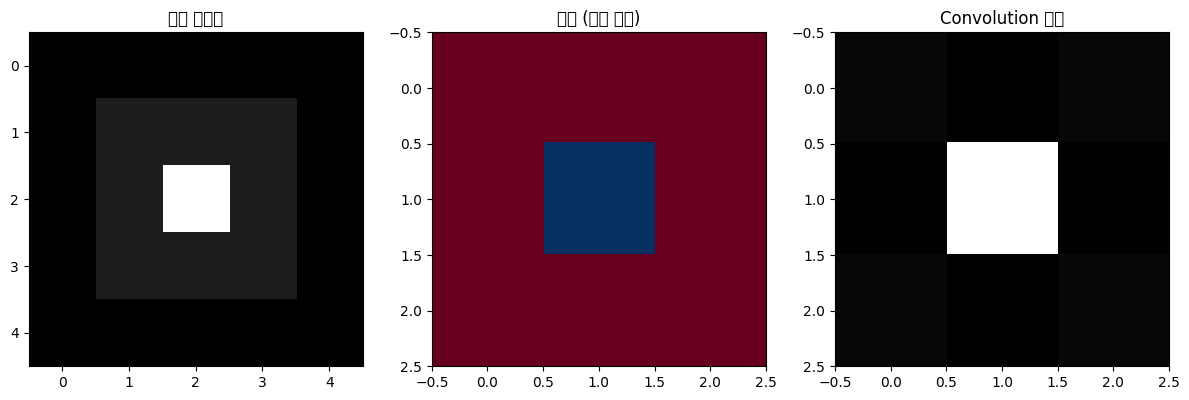

In [2]:
import numpy as np
import matplotlib.pyplot as plt

image = np.array([
    [0,0,0,0,0],
    [0,1,1,1,0],
    [0,1,9,1,0],
    [0,1,1,1,0],
    [0,0,0,0,0]
], dtype=float)

filter_edge = np.array([
    [-1,-1,-1],
    [-1,8,-1],
    [-1,-1,-1]
], dtype=float)

output = np.zeros((3,3))

for i in range (3):
    for j in range(3):
        patch = image[i:i+3, j:j+3]
        output[i,j] = np.sum(patch*filter_edge)

print("원본 이미지:")
print(image)
print("\n필터 적용 결과 (엣지 강조):")
print(output)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('원본 이미지')
axes[1].imshow(filter_edge, cmap='RdBu')
axes[1].set_title('필터 (엣지 검출)')
axes[2].imshow(output, cmap='gray')
axes[2].set_title('Convolution 결과')
plt.tight_layout()
plt.show()

Feature Map (Convolution 결과):
[[1. 3. 2. 4.]
 [5. 6. 1. 2.]
 [3. 2. 1. 0.]
 [1. 2. 3. 4.]]

Max Pooling 결과 (2×2):
[[6. 4.]
 [3. 4.]]


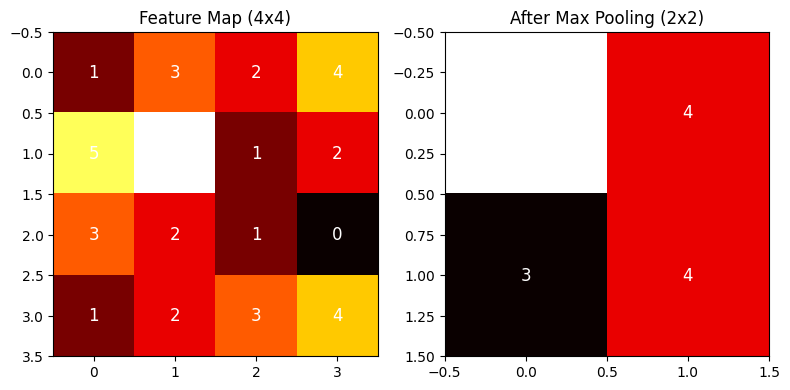

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 4×4 feature map (Convolution 결과라고 가정)
feature_map = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [3, 2, 1, 0],
    [1, 2, 3, 4]
], dtype=float)

# Max Pooling (2×2, stride=2)
pool_output = np.zeros((2, 2))

for i in range(2):
    for j in range(2):
        patch = feature_map[i*2:i*2+2, j*2:j*2+2]
        pool_output[i, j] = np.max(patch)

print("Feature Map (Convolution 결과):")
print(feature_map)
print("\nMax Pooling 결과 (2×2):")
print(pool_output)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(feature_map, cmap='hot')
axes[0].set_title('Feature Map (4x4)')
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, int(feature_map[i,j]),
                    ha='center', va='center', color='white', fontsize=12)

axes[1].imshow(pool_output, cmap='hot')
axes[1].set_title('After Max Pooling (2x2)')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, int(pool_output[i,j]),
                    ha='center', va='center', color='white', fontsize=12)

plt.tight_layout()
plt.show()

In [4]:
import torch
import torch.nn as nn
import numpy as np

X_train = np.load('data/X_train.npy')
y_train = np.load('data/y_train.npy')
X_val   = np.load('data/X_val.npy')
y_val   = np.load('data/y_val.npy')

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1096, 562)
y_train shape: (1096,)


In [5]:
# numpy → PyTorch tensor 변환
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.LongTensor(y_val)

print("✅ Tensor 변환 완료!")
print("X_train_t shape:", X_train_t.shape)
print("y_train_t dtype:", y_train_t.dtype)

✅ Tensor 변환 완료!
X_train_t shape: torch.Size([1096, 562])
y_train_t dtype: torch.int64


In [6]:
import torch.nn as nn

class MLPClassifier(nn.Module):
    def __init__(self, input_dim=562):
        super(MLPClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.model(x)

# 모델 생성
model = MLPClassifier(input_dim=562)
print(model)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}개")

MLPClassifier(
  (model): Sequential(
    (0): Linear(in_features=562, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

총 파라미터 수: 160,706개


In [7]:
# GPU 사용 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

# 모델을 GPU로 이동
model = model.to(device)
X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)
X_val_t = X_val_t.to(device)
y_val_t = y_val_t.to(device)

# Loss 함수 + Optimizer 정의
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("✅ 학습 준비 완료!")
print(f"Loss 함수: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.001)")

사용 장치: cuda
✅ 학습 준비 완료!
Loss 함수: CrossEntropyLoss
Optimizer: Adam (lr=0.001)


In [8]:
# 학습 루프
epochs = 50
train_losses = []
val_losses = []

for epoch in range(epochs):
    # 학습 모드
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    output = model(X_train_t)
    loss = criterion(output, y_train_t)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # 검증 모드
    model.eval()
    with torch.no_grad():
        val_output = model(X_val_t)
        val_loss = criterion(val_output, y_val_t)
        val_losses.append(val_loss.item())
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {loss.item():.4f} "
              f"Val Loss: {val_loss.item():.4f}")

Epoch [10/50] Train Loss: 0.2554 Val Loss: 0.2392
Epoch [20/50] Train Loss: 0.1634 Val Loss: 0.2343
Epoch [30/50] Train Loss: 0.1038 Val Loss: 0.2652
Epoch [40/50] Train Loss: 0.0731 Val Loss: 0.2967
Epoch [50/50] Train Loss: 0.0511 Val Loss: 0.3358


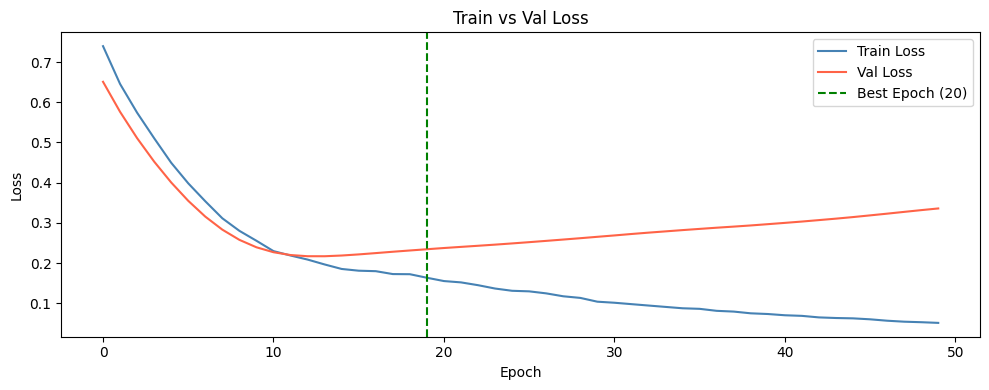

Train Accuracy: 98.8%
Val Accuracy:   94.0%


In [9]:
import matplotlib.pyplot as plt

# 학습 곡선 시각화
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses, label='Val Loss', color='tomato')
plt.axvline(x=19, color='green', linestyle='--', label='Best Epoch (20)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Val Loss')
plt.legend()
plt.tight_layout()
plt.show()

# 정확도 확인
model.eval()
with torch.no_grad():
    train_pred = model(X_train_t).argmax(dim=1)
    val_pred   = model(X_val_t).argmax(dim=1)

train_acc = (train_pred == y_train_t).float().mean().item()
val_acc   = (val_pred == y_val_t).float().mean().item()

print(f"Train Accuracy: {train_acc*100:.1f}%")
print(f"Val Accuracy:   {val_acc*100:.1f}%")

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

# CPU로 변환해서 sklearn에 넣기
y_val_np   = y_val_t.cpu().numpy()
y_pred_np  = val_pred.cpu().numpy()

print("=== Classification Report ===")
print(classification_report(y_val_np, y_pred_np,
      target_names=['정상(0)', '불량(1)']))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_val_np, y_pred_np))

=== Classification Report ===
              precision    recall  f1-score   support

       정상(0)       0.94      1.00      0.97       220
       불량(1)       1.00      0.07      0.12        15

    accuracy                           0.94       235
   macro avg       0.97      0.53      0.55       235
weighted avg       0.94      0.94      0.92       235

=== Confusion Matrix ===
[[220   0]
 [ 14   1]]


In [11]:
# 불량 클래스에 더 높은 가중치 부여
# 불량(1)이 정상(0)보다 14배 적으니까 → 14배 가중치
class_weights = torch.FloatTensor([1.0, 14.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 모델 새로 초기화
model = MLPClassifier(input_dim=562).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 재학습
epochs = 50
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_t)
    loss = criterion(output, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_output = model(X_val_t)
        val_loss = criterion(val_output, y_val_t)
        val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {loss.item():.4f} "
              f"Val Loss: {val_loss.item():.4f}")

Epoch [10/50] Train Loss: 0.4589 Val Loss: 0.6302
Epoch [20/50] Train Loss: 0.1858 Val Loss: 1.0982
Epoch [30/50] Train Loss: 0.0456 Val Loss: 1.9311
Epoch [40/50] Train Loss: 0.0095 Val Loss: 2.5689
Epoch [50/50] Train Loss: 0.0029 Val Loss: 2.9207


In [12]:
# 개선된 재학습
class_weights = torch.FloatTensor([1.0, 5.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

model = MLPClassifier(input_dim=562).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Early Stopping 설정
best_val_loss = float('inf')
patience = 10       # 10 epoch 동안 개선 없으면 중단
counter = 0
best_model_state = None

epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_t)
    loss = criterion(output, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_output = model(X_val_t)
        val_loss = criterion(val_output, y_val_t)
        val_losses.append(val_loss.item())

    # Early Stopping 체크
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict().copy()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"\n⏹ Early Stopping! Epoch {epoch+1}에서 중단")
            break

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}] "
              f"Train: {loss.item():.4f} "
              f"Val: {val_loss.item():.4f} "
              f"[patience: {counter}/{patience}]")

# 최적 모델 복원
model.load_state_dict(best_model_state)
print(f"\n✅ Best Val Loss: {best_val_loss:.4f} 모델 복원 완료!")

Epoch [10] Train: 0.4029 Val: 0.5513 [patience: 3/10]

⏹ Early Stopping! Epoch 17에서 중단

✅ Best Val Loss: 0.5411 모델 복원 완료!


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
with torch.no_grad():
    val_pred = model(X_val_t).argmax(dim=1)

y_val_np  = y_val_t.cpu().numpy()
y_pred_np = val_pred.cpu().numpy()

print("=== Classification Report ===")
print(classification_report(y_val_np, y_pred_np,
      target_names=['정상(0)', '불량(1)']))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_val_np, y_pred_np))

=== Classification Report ===
              precision    recall  f1-score   support

       정상(0)       0.94      0.97      0.95       220
       불량(1)       0.12      0.07      0.09        15

    accuracy                           0.91       235
   macro avg       0.53      0.52      0.52       235
weighted avg       0.89      0.91      0.90       235

=== Confusion Matrix ===
[[213   7]
 [ 14   1]]


In [14]:
# Threshold 조정 실험
model.eval()
with torch.no_grad():
    val_output = model(X_val_t)
    # 소프트맥스로 확률 변환
    probs = torch.softmax(val_output, dim=1)
    # 불량(1) 확률
    prob_defect = probs[:, 1].cpu().numpy()

# 여러 Threshold 비교
from sklearn.metrics import f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
print("Threshold별 불량 F1-score:")
print("-" * 35)
for t in thresholds:
    pred = (prob_defect >= t).astype(int)
    f1 = f1_score(y_val_t.cpu().numpy(), pred)
    print(f"Threshold {t:.1f} → 불량 F1: {f1:.3f}")

Threshold별 불량 F1-score:
-----------------------------------
Threshold 0.1 → 불량 F1: 0.215
Threshold 0.2 → 불량 F1: 0.276
Threshold 0.3 → 불량 F1: 0.150
Threshold 0.4 → 불량 F1: 0.133
Threshold 0.5 → 불량 F1: 0.087


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Threshold 0.2로 최종 예측
best_pred = (prob_defect >= 0.2).astype(int)

print("=== Threshold 0.2 최종 결과 ===")
print(classification_report(y_val_t.cpu().numpy(), best_pred,
      target_names=['정상(0)', '불량(1)']))

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_val_t.cpu().numpy(), best_pred)
print(cm)
print(f"\n불량 탐지: {cm[1,1]}개 맞춤 / 전체 {cm[1,0]+cm[1,1]}개")

=== Threshold 0.2 최종 결과 ===
              precision    recall  f1-score   support

       정상(0)       0.96      0.84      0.90       220
       불량(1)       0.19      0.53      0.28        15

    accuracy                           0.82       235
   macro avg       0.57      0.69      0.59       235
weighted avg       0.91      0.82      0.86       235

=== Confusion Matrix ===
[[185  35]
 [  7   8]]

불량 탐지: 8개 맞춤 / 전체 15개


In [18]:
import subprocess
subprocess.run(['pip','install','imbalanced-learn'], capture_output=True)

from imblearn.over_sampling import SMOTE
import numpy as np

print("SMOTE 적용 전:")
print(f"정상(0): {(y_train == 0).sum()}개")
print(f"불량(1): {(y_train == 1).sum()}개")

smote = SMOTE (random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("\nSMOTE 적용 후:")
print(f"정상(0): {(y_resampled == 0).sum()}개")
print(f"불량(1): {(y_resampled == 1).sum()}개")
print(f"\n총 데이터: {len(X_resampled)}개")


SMOTE 적용 전:
정상(0): 1023개
불량(1): 73개

SMOTE 적용 후:
정상(0): 1023개
불량(1): 1023개

총 데이터: 2046개


In [19]:
# SMOTE 데이터로 tensor 변환
X_train_sm = torch.FloatTensor(X_resampled).to(device)
y_train_sm = torch.LongTensor(y_resampled).to(device)

# 모델 새로 초기화 (Class Weight 없이! 데이터 자체가 균형잡혔으니)
model_smote = MLPClassifier(input_dim=562).to(device)
criterion_smote = nn.CrossEntropyLoss()  # weight 없음
optimizer_smote = torch.optim.Adam(model_smote.parameters(), lr=0.001)

# Early Stopping 재설정
best_val_loss = float('inf')
patience = 10
counter = 0
best_model_state = None

for epoch in range(100):
    model_smote.train()
    optimizer_smote.zero_grad()
    output = model_smote(X_train_sm)
    loss = criterion_smote(output, y_train_sm)
    loss.backward()
    optimizer_smote.step()

    model_smote.eval()
    with torch.no_grad():
        val_output = model_smote(X_val_t)
        val_loss = criterion_smote(val_output, y_val_t)

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = {k: v.clone() for k, v in model_smote.state_dict().items()}
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early Stopping! Epoch {epoch+1}")
            break

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}] Train: {loss.item():.4f} Val: {val_loss.item():.4f}")

model_smote.load_state_dict(best_model_state)
print(f"\n✅ SMOTE 모델 학습 완료!")

Epoch [10] Train: 0.4186 Val: 0.3980
Epoch [20] Train: 0.1368 Val: 0.3242
Early Stopping! Epoch 30

✅ SMOTE 모델 학습 완료!


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

model_smote.eval()
with torch.no_grad():
    val_pred_smote = model_smote(X_val_t).argmax(dim=1)

# Threshold 0.2도 같이 적용해서 비교
probs_smote = torch.softmax(model_smote(X_val_t), dim=1)
prob_defect_smote = probs_smote[:, 1].cpu().numpy()
val_pred_smote_t02 = (prob_defect_smote >= 0.2).astype(int)

y_val_np = y_val_t.cpu().numpy()

print("=== SMOTE + Threshold 0.5 (기본) ===")
print(classification_report(y_val_np, val_pred_smote.cpu().numpy(),
      target_names=['정상(0)', '불량(1)']))

print("=== SMOTE + Threshold 0.2 ===")
print(classification_report(y_val_np, val_pred_smote_t02,
      target_names=['정상(0)', '불량(1)']))

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

model_smote.eval()
with torch.no_grad():
    val_pred_smote = model_smote(X_val_t).argmax(dim=1)
    probs_smote = torch.softmax(model_smote(X_val_t), dim=1)

prob_defect_smote = probs_smote[:, 1].detach().cpu().numpy()
val_pred_smote_t02 = (prob_defect_smote >= 0.2).astype(int)

y_val_np = y_val_t.cpu().numpy()

print("=== SMOTE + Threshold 0.5 (기본) ===")
print(classification_report(y_val_np, val_pred_smote.cpu().numpy(),
      target_names=['정상(0)', '불량(1)']))

print("=== SMOTE + Threshold 0.2 ===")
print(classification_report(y_val_np, val_pred_smote_t02,
      target_names=['정상(0)', '불량(1)']))

=== SMOTE + Threshold 0.5 (기본) ===
              precision    recall  f1-score   support

       정상(0)       0.95      0.94      0.94       220
       불량(1)       0.19      0.20      0.19        15

    accuracy                           0.89       235
   macro avg       0.57      0.57      0.57       235
weighted avg       0.90      0.89      0.90       235

=== SMOTE + Threshold 0.2 ===
              precision    recall  f1-score   support

       정상(0)       0.96      0.84      0.90       220
       불량(1)       0.17      0.47      0.25        15

    accuracy                           0.82       235
   macro avg       0.56      0.65      0.57       235
weighted avg       0.91      0.82      0.85       235

